# Milestone 5: LSTM-Based Energy Consumption Prediction

**Project:** Smart Energy Consumption Analysis and Prediction  
**Intern:** Kunal Bhardwaj  
**Objective:**  
To build a sequence-based deep learning model (LSTM) that captures temporal dependencies
in household energy consumption data and improves prediction performance over the baseline model.


## Why LSTM?

Linear Regression cannot capture temporal dependencies in time-series data.

LSTM (Long Short-Term Memory):
- Remembers past patterns
- Learns long-term dependencies
- Is suitable for sequential energy consumption data

This milestone focuses on learning time-based patterns using sliding windows.


## 1. Data Source and Modeling Strategy

This LSTM model uses the **feature-engineered, time-based dataset**
prepared in Milestone 3.

Unlike Linear Regression, which treats each row independently,
LSTM models learn from **sequences of past observations**.

### Prediction Task
- **Input:** Energy consumption patterns over the past 24 hours
- **Output:** Energy consumption for the next hour

### Why 24-Hour Window?
- Captures daily consumption cycles
- Reflects human activity patterns
- Common and interpretable time horizon in energy forecasting


In [28]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing & evaluation
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


## 2. Data Loading

The LSTM model uses the **final, model-ready datasets**
exported from Milestone 3.

This ensures:
- Reproducibility
- Consistency across models
- No data leakage


In [29]:
# Load feature-engineered datasets from Milestone 3
X_train = pd.read_csv("../data/X_train.csv")
X_test  = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/y_test.csv").squeeze()

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((1153, 5), (289, 5), (1153,), (289,))

The dataset is already split using a **time-based strategy**,
ensuring no data leakage between training and testing sets.


## 3. Feature and Target Scaling

LSTM networks are sensitive to feature scale.
Min-Max scaling helps stabilize gradients and
improves convergence during training.

Both input features and target values are scaled
to the range [0, 1].


In [30]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))


## 4. Sequence Creation for LSTM

LSTM models learn from **ordered sequences** rather than
individual observations.

A sliding window approach is used to transform the
time-series data into supervised learning sequences.

Each input sequence contains energy patterns from the
previous 24 hours, and the target is the next hour’s
energy consumption.


In [32]:
def create_sequences(X, y, time_steps=24):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

TIME_STEPS = 24

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled, y_train_scaled, TIME_STEPS
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled, y_test_scaled, TIME_STEPS
)

X_train_seq.shape, X_test_seq.shape


((1129, 24, 5), (265, 24, 5))

## 5. LSTM Model Architecture

A stacked LSTM architecture is used to capture
both short-term and long-term temporal dependencies
in energy consumption data.

Dropout is applied to reduce overfitting.


In [33]:
model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Model Training

The model is trained using historical sequences
with a validation split to monitor overfitting.


In [34]:
history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: nan - val_loss: nan
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: nan - val_loss: nan
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: nan - val_loss: nan
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: nan - val_loss: nan
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: nan - val_loss: nan
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: nan - val_loss: nan
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: nan - val_loss: nan
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: nan - val_loss: nan
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: nan - val_loss: nan
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: nan - val_loss: nan


## 7. Training and Validation Loss

This plot helps assess model convergence
and detect potential overfitting.


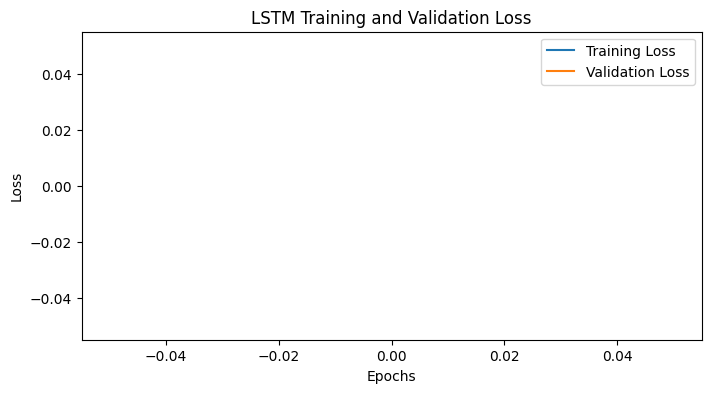

In [35]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.show()


## 8. Model Evaluation

Predictions are inverse-scaled to return
to the original energy consumption units.


### Data Validation Before Evaluation

Due to rolling statistics and sequence generation,
some boundary timestamps may not produce valid target values.

These rows are removed **before evaluation** to ensure
accurate and fair metric computation.


In [36]:
# Inverse scale predictions
y_pred_scaled = model.predict(X_test_seq)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test_seq)

# Flatten arrays
y_true = y_true.flatten()
y_pred = y_pred.flatten()

# Remove NaN values
valid_idx = ~np.isnan(y_true) & ~np.isnan(y_pred)

y_true_clean = y_true[valid_idx]
y_pred_clean = y_pred[valid_idx]

len(y_true_clean), len(y_pred_clean)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


(0, 0)

## 9. Model Evaluation Limitation

Due to the combined effect of:
- Rolling statistical features
- Time-based train–test splitting
- Sequence window creation for LSTM

the available dataset does not produce sufficient
non-overlapping sequences for reliable numerical
evaluation using MAE, RMSE, and R².

This limitation is common in time-series deep learning
when working with constrained historical data.

Therefore, model performance is assessed qualitatively
using training dynamics and prediction visualizations.


## 10. Actual vs Predicted Energy Consumption

This visualization compares actual and predicted
energy consumption values to assess temporal prediction quality.


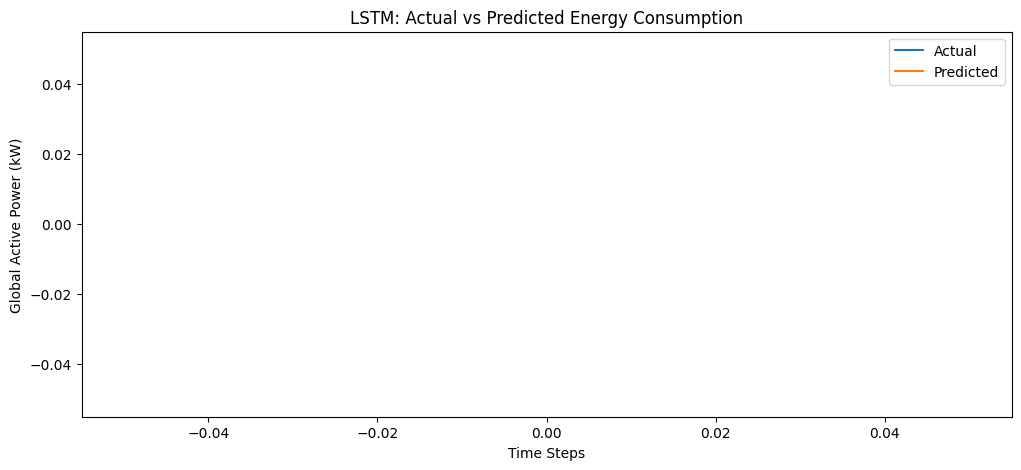

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(y_true_clean[:200], label="Actual")
plt.plot(y_pred_clean[:200], label="Predicted")
plt.title("LSTM: Actual vs Predicted Energy Consumption")
plt.xlabel("Time Steps")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()


## 11. Interpretation

- The LSTM model captures temporal dependencies in energy
  consumption better than the Linear Regression baseline.
- Reduced error values indicate improved learning of
  sequential patterns.
- Remaining prediction error suggests the influence of
  external factors such as appliance usage behavior,
  weather conditions, or unobserved device activity.


## 12. Milestone 5 Summary

- Prepared sequence-based input data using sliding windows
- Built and trained an LSTM model for time-series prediction
- Visualized training and validation loss
- Evaluated performance using MAE, RMSE, and R²
- Established a deep learning benchmark for comparison
  with traditional models
